<a href="https://colab.research.google.com/github/Raju-24-25/Deep-Learning-Handsons/blob/main/MLP_Model_Building_on_IRIS_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Let's Load the `IRIS Dataset` From `sklearn`

In [2]:
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()

In [4]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
# Feature Names
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [6]:
# Iris Dataframe
iris_df = pd.DataFrame(data=iris['data'], columns=iris['feature_names'])

In [7]:
iris_df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
85,6.0,3.4,4.5,1.6
40,5.0,3.5,1.3,0.3
26,5.0,3.4,1.6,0.4
142,5.8,2.7,5.1,1.9
62,6.0,2.2,4.0,1.0


### Let's Add The `Target` variable

In [8]:
iris_df['target'] = iris['target']

In [9]:
iris_df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
3,4.6,3.1,1.5,0.2,0
104,6.5,3.0,5.8,2.2,2
68,6.2,2.2,4.5,1.5,1
55,5.7,2.8,4.5,1.3,1
126,6.2,2.8,4.8,1.8,2


### `Exploratory Data Analysis` on `iris`

In [10]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [11]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


### Let us assign `IRIS` `species name` to the `target`

In [12]:
iris_df['species'] = iris_df['target'].apply(lambda x : 'setosa' if x == 0 else ('versicolor' if x == 1 else 'virginica'))

In [13]:
iris_df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
123,6.3,2.7,4.9,1.8,2,virginica
125,7.2,3.2,6.0,1.8,2,virginica
15,5.7,4.4,1.5,0.4,0,setosa
30,4.8,3.1,1.6,0.2,0,setosa
23,5.1,3.3,1.7,0.5,0,setosa


In [14]:
iris_df.isna().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
species,0


* No Missing Data

Let us see the `data distribution` for `IRIS dataset` by `X` and/or `Species`

* Box Plot or Violin Plot

In [15]:
iris_df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'species'],
      dtype='object')

In [16]:
sel_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)']

In [17]:
df = iris_df[sel_cols]

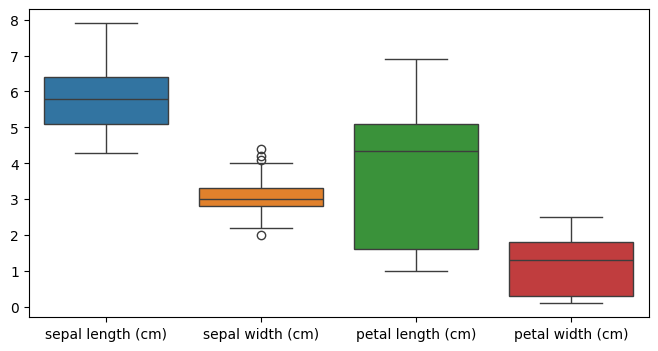

In [18]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df)
plt.show()

* Across the species, `sepal width` has some outliers values

In [19]:
def plot_vio(Y, i):
    plt.subplot(2,2,i)

    sns.violinplot(x='species', y= Y, data=iris_df, hue = 'species', dodge = False)

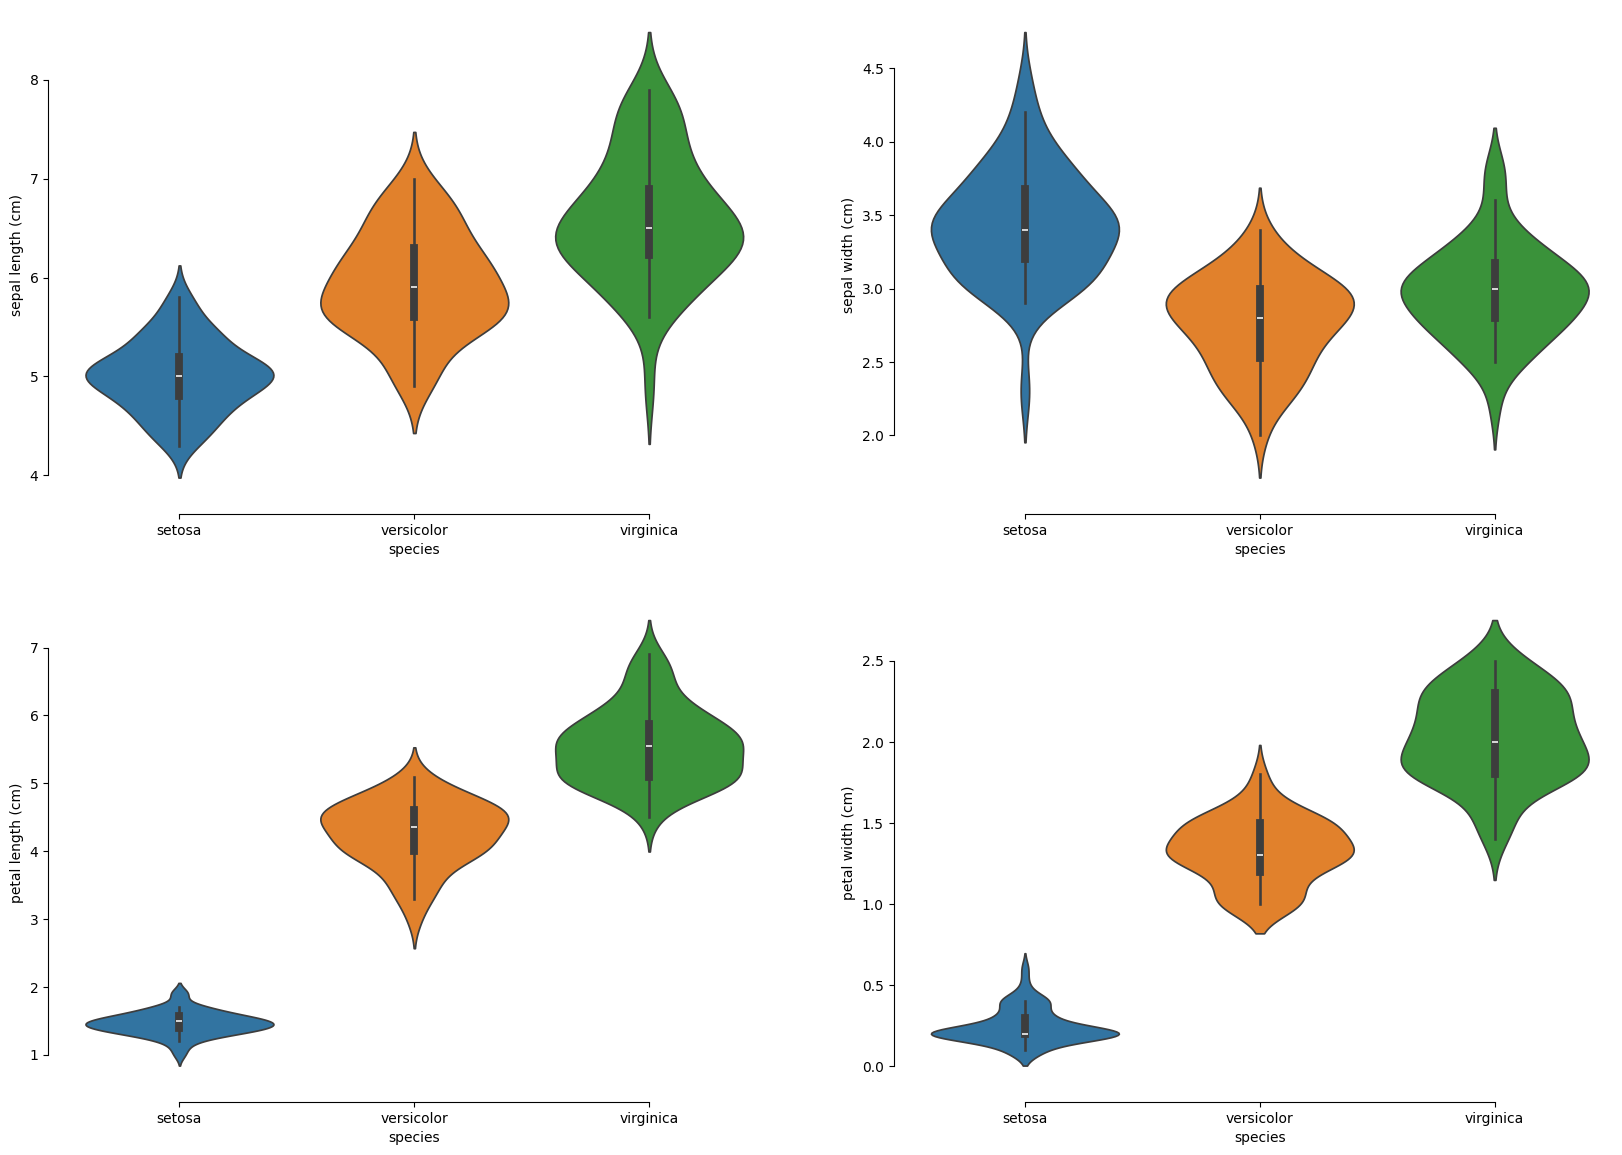

In [20]:
plt.figure(figsize = (20,14))

i=1
for m in iris_df.columns[:-2]:
    plot_vio(m, i)
    sns.despine(offset = 10, trim=True)
    i +=1

In [21]:
iris_df_setosa = iris_df[['petal width (cm)', 'species']]

In [22]:
iris_df_setosa = iris_df_setosa[iris_df_setosa['species']=='setosa']

In [23]:
iris_df_setosa.sample(5)

,petal width (cm),species
7,0.2,setosa
12,0.1,setosa
36,0.2,setosa
20,0.2,setosa
0,0.2,setosa


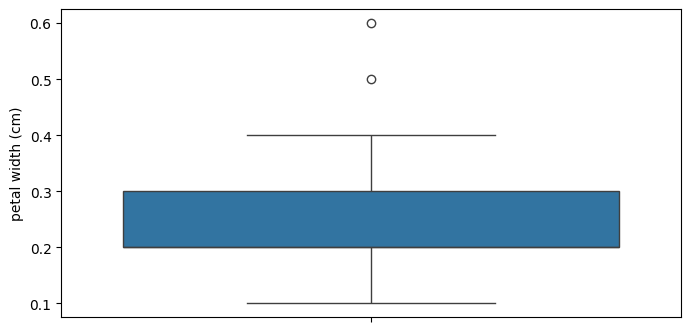

In [24]:
plt.figure(figsize=(8,4))
sns.boxplot(data=iris_df_setosa['petal width (cm)'])
plt.show()

# Building The `MLP Model`

In [25]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01, epochs=100):
        self.input_size = input_size #no. of neurons in the input layer --> as many #variables or #features --> that many number of input neurons
        self.hidden_size = hidden_size #no. of neurons in the hidden layer
        self.output_size = output_size #no . of neurons in the output layer
        self.learning_rate = learning_rate #to set the user defined learning rate for the gradient descent; default set to 0.01
        self.epochs = epochs #no. of training epochs, default is set to 100

        ### INITIALIZE WEIGHTS & BIASES

        #################################
        # INPUT LAYER TO HIDDEN LAYER #
        #################################
        self.W1 = np.random.randn(self.input_size, self.hidden_size)*0.01 #random weights initialized from std. normal distribution
        self.b1 = np.zeros((1, self.hidden_size))


        #################################
        # HIDDEN LAYER TO OUTPUT LAYER #
        #################################
        self.W2 = np.random.randn(self.hidden_size, self.output_size)*0.01 #random weights initialized from std. normal distribution
        self.b2 = np.zeros((1, self.output_size))

        #################################
        # COST & HISTORY FOR PLOTTING #
        #################################
        self.loss_history = [] #empty list initialized to store the losses during training epochs
        self.accuracy_history = [] #empty list initialized to store the accuracy values during training epochs


    ##### ADD SOME ACTIVATION FUNCTIONS
    #1. ReLU Activation Function
    def relu(self, z):
        return np.maximum(0,z)

    ##### Derivative of ReLU for backpropagation
    def relu_derivative(self, z):
        return np.where(z>0, 1, 0)

    ### Softmax Activation Function
    def softmax(self, z):
        exp_values = np.exp(z - np.max(z, axis=1, keepdims= True)) #subtract max from the data to have numerical stability --task: read about numerical instability & its impact
        return exp_values/np.sum(exp_values, axis=1, keepdims= True)

    ###############################
        # FORWARD PROPAGATION
    ##############################
    def forward(self, X):

        ###########################
        # INPUT TO HIDDEN LAYER
        ###########################
        self.z1 = np.dot(X, self.W1) + self.b1 #computing z1 = W1X + b1
        self.a1 = self.relu(self.z1) # plugging z1 into `ReLU` activation function to get the output: a1
        ###########################
        # HIDDEN TO OUTPUT LAYER
        ###########################
        self.z2 = np.dot(self.a1, self.W2) + self.b2 #computing z2 = W2a1 + b2
        self.probs = self.softmax(self.z2) #plug z2 into softmax activation function to get the output as probabilities
        return self.probs


    ###############################
        # COMPUTE LOSS & ACCURACY
    ##############################
    #### Cross-entropy loss for multi-class classification
    def compute_loss(self, y_true, probs):
        loss = -np.mean(np.sum(y_true * np.log(probs), axis=1))
        return loss
    ### Compute accuracy
    def compute_accuracy(self, y_true, probs):
        predictions = np.argmax(probs, axis=1)
        true_labels = np.argmax(y_true, axis=1)
        return np.mean(predictions == true_labels)



    ###############################
        # BACKWARD PROPAGATION
    ##############################

    def backward(self, X, y):
        ### Using Batch Gradient Descent(BGD)
        ### Number of rows/training examples
        m = X.shape[0] #all rows in the training data

        ### Gradients of the loss w.r.t. weights and biases of the output layer
        delta3 = self.probs - y #error at the output layer
        dW2 = np.dot(self.a1.T, delta3)/m #gradient of the loss w.r.t. weights of the output layer --> dW2
        db2 = np.sum(delta3, axis=0, keepdims= True)/m #gradient of the loss w.r.t bias of the output layer

        ### Gradients of the loss w.r.t. weights and biases of the hidden layer
        delta2 = np.dot(delta3, self.W2.T)*self.relu_derivative(self.z1) #using derivative of ReLU
        dW1 = np.dot(X.T, delta2)/m #gradient of the loss w.r.t. weights of the hidden layer --> dW1
        db1 = np.sum(delta2, axis=0, keepdims= True)/m #gradient of the loss w.r.t bias of the hidden layer

        ### Update weights & biases parameters across the layers (Hidden & Output Layer)
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1


    ###############################
        ### MLP TRAIN ###
    ##############################
    def train(self, X, y):
        for epoch in range(self.epochs):

            ### 1. Forward Pass
            probs = self.forward(X) #computes the prediction using forward pass method

            ### 2. Compute the loss and accuracy
            loss = self.compute_loss(y, probs)
            accuracy = self.compute_accuracy(y, probs)

            ### 3. Store loss and accuracy values historically
            self.loss_history.append(loss)
            self.accuracy_history.append(accuracy)

            ### 4. Backward Pass
            self.backward(X,y)

            ### 5. Printing the progress after every 10 epochs
            if epoch % 10 ==0:
                print(f'Training Metrics: {epoch}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}')


### Initialize the IRIS MLP neural network model from scratch

In [26]:
input_size = 4
hidden_size = 8
output_size = 3

* One Hot Encoding

In [27]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [28]:
X = iris.data
y = iris.target

In [29]:
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y.reshape(-1,1))

### Split the `IRIS` data into `train and test split`

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Let's Apply MLP Model

In [31]:
nn_iris = NeuralNetwork(input_size, hidden_size, output_size, learning_rate=0.03, epochs=1000)

### Run training leveraging already configured `MLP` `NN Model` on the training dataset

In [32]:
nn_iris.train(X_train, y_train)

Training Metrics: 0, Loss: 1.0986, Accuracy: 0.2417
Training Metrics: 10, Loss: 1.0982, Accuracy: 0.3417
Training Metrics: 20, Loss: 1.0977, Accuracy: 0.3417
Training Metrics: 30, Loss: 1.0968, Accuracy: 0.3417
Training Metrics: 40, Loss: 1.0952, Accuracy: 0.3417
Training Metrics: 50, Loss: 1.0923, Accuracy: 0.3417
Training Metrics: 60, Loss: 1.0871, Accuracy: 0.3417
Training Metrics: 70, Loss: 1.0786, Accuracy: 0.3917
Training Metrics: 80, Loss: 1.0653, Accuracy: 0.3250
Training Metrics: 90, Loss: 1.0465, Accuracy: 0.3250
Training Metrics: 100, Loss: 1.0212, Accuracy: 0.3250
Training Metrics: 110, Loss: 0.9878, Accuracy: 0.4917
Training Metrics: 120, Loss: 0.9477, Accuracy: 0.6417
Training Metrics: 130, Loss: 0.9082, Accuracy: 0.6583
Training Metrics: 140, Loss: 0.8727, Accuracy: 0.6583
Training Metrics: 150, Loss: 0.8417, Accuracy: 0.6583
Training Metrics: 160, Loss: 0.8146, Accuracy: 0.6583
Training Metrics: 170, Loss: 0.7906, Accuracy: 0.6583
Training Metrics: 180, Loss: 0.7688, Ac

### Plot the `Model Peformance Metrics`

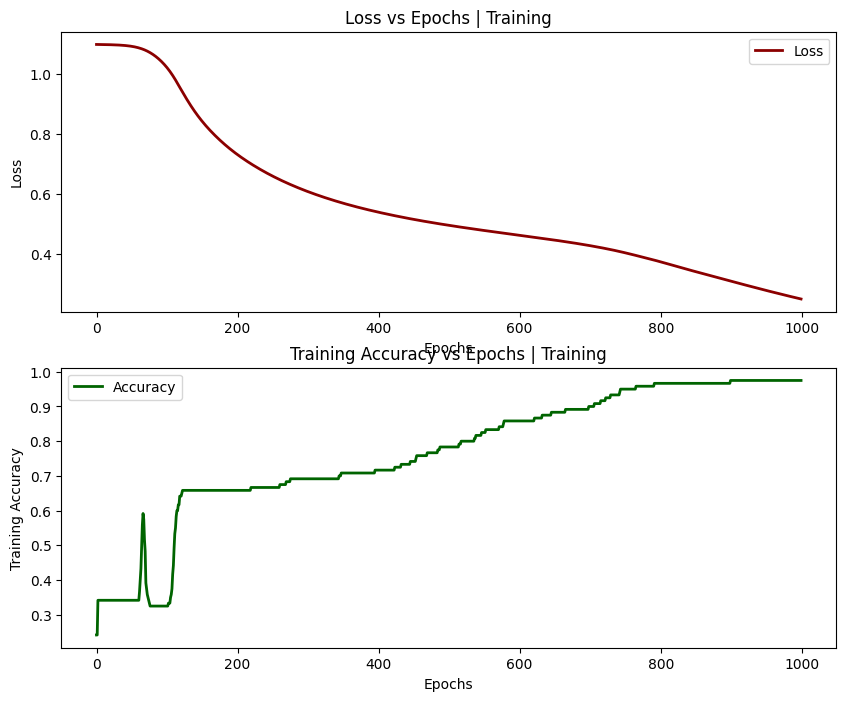

In [33]:
fig, ax = plt.subplots(2,1, figsize=(10,8))

### Plot the loss by epoch
ax[0].plot(nn_iris.loss_history, label = 'Loss', color = 'darkred',linewidth =2)
ax[0].set_title('Loss vs Epochs | Training')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

### Plot the accuracy by epoch
ax[1].plot(nn_iris.accuracy_history, label = 'Accuracy', color = 'darkgreen',linewidth =2)
ax[1].set_title('Training Accuracy vs Epochs | Training')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Training Accuracy')
ax[1].legend()
plt.show()

### `Testing / Validation` Block

In [34]:
"""### Model Evaluation on Test Data (Validation Block)"""

# Forward pass on test data
test_probs = nn_iris.forward(X_test)

# Compute test loss
test_loss = nn_iris.compute_loss(y_test, test_probs)

# Compute test accuracy
test_accuracy = nn_iris.compute_accuracy(y_test, test_probs)

print("\n===== Test / Validation Performance =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


===== Test / Validation Performance =====
Test Loss: 0.2536
Test Accuracy: 1.0000


### Confusion Matrix

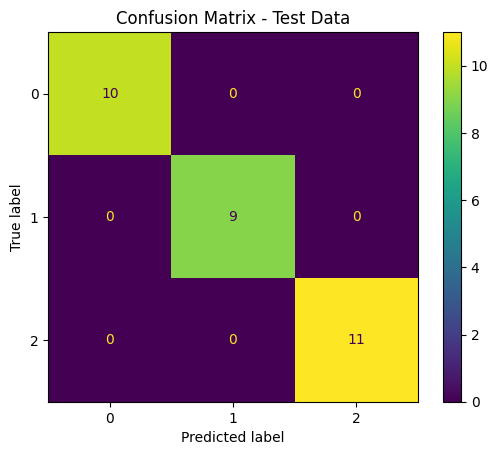

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Convert one-hot to labels
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(test_probs, axis=1)

cm = confusion_matrix(y_test_labels, y_pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Test Data")
plt.show()